## Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter

## Data Import

In [2]:
# Set the path to the file you'd like to load
file_path = "MrBeast_youtube_stats.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "robikscube/mrbeast-youtube-stats-daily",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_11459/2014574349.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 424M/424M [00:04<00:00, 89.6MB/s]


First 5 records:             id                             title description  \
0  nAiKLoCP-kU      Reach the Money, Win $10,000         NaN   
1  8krJy31Diow    Holding Bigger And Bigger Dogs         NaN   
2  R_BmT1OJw98  Every YouTube Play Button I Have         NaN   
3  oiZvK6MY7tI         Call Your Ex, Win $10,000         NaN   
4  CWbV3NItSdY  The World&#39;s Fastest Cleaners         NaN   

                 publishTime     kind_stats  duration_seconds    viewCount  \
0  2025-02-14 18:15:00+00:00  youtube#video                25  522570530.0   
1  2024-09-16 18:00:00+00:00  youtube#video                17  347052229.0   
2  2025-08-15 16:00:01+00:00  youtube#video                15  258744376.0   
3  2025-10-07 16:00:00+00:00  youtube#video                34  120576799.0   
4  2024-04-25 16:00:03+00:00  youtube#video                35  723498306.0   

    likeCount  commentCount                          thumbnails.default.url  \
0   7948390.0       10612.0  https://i.ytimg.com/v

## Explore Data Summary


In [3]:
df.info()
print("\n")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455103 entries, 0 to 455102
Data columns (total 26 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   id                            453804 non-null  object 
 1   title                         455103 non-null  object 
 2   description                   424985 non-null  object 
 3   publishTime                   455103 non-null  object 
 4   kind_stats                    453804 non-null  object 
 5   duration_seconds              455103 non-null  int64  
 6   viewCount                     453804 non-null  float64
 7   likeCount                     452312 non-null  float64
 8   commentCount                  452732 non-null  float64
 9   thumbnails.default.url        455103 non-null  object 
 10  thumbnails.default.width      454384 non-null  float64
 11  thumbnails.default.height     454384 non-null  float64
 12  thumbnails.medium.url         455103 non-nul

,duration_seconds,viewCount,likeCount,commentCount,thumbnails.default.width,thumbnails.default.height,thumbnails.medium.width,thumbnails.medium.height,thumbnails.high.width,thumbnails.high.height
count,455103.000000,4.538040e+05,4.523120e+05,452732.000000,454384.0,454384.0,454384.0,454384.0,454384.0,454384.0
mean,1341.092214,1.016644e+08,2.975815e+06,64357.814997,120.0,90.0,320.0,180.0,480.0,360.0
std,6763.201419,1.384981e+08,4.949561e+06,79566.929078,0.0,0.0,0.0,0.0,0.0,0.0
min,0.000000,0.000000e+00,0.000000e+00,0.000000,120.0,90.0,320.0,180.0,480.0,360.0
25%,213.000000,4.454870e+05,1.492875e+04,1624.000000,120.0,90.0,320.0,180.0,480.0,360.0
50%,650.000000,5.791248e+07,1.578005e+06,45980.500000,120.0,90.0,320.0,180.0,480.0,360.0
75%,909.000000,1.526218e+08,3.797674e+06,96447.250000,120.0,90.0,320.0,180.0,480.0,360.0
max,86402.000000,1.639755e+09,5.711583e+07,798700.000000,120.0,90.0,320.0,180.0,480.0,360.0


## Handle Missing Data and Convert Data Types


In [4]:
df['publishTime'] = pd.to_datetime(df['publishTime'], errors='coerce')
df.dropna(subset=['publishTime'], inplace=True)

df.dropna(subset=['viewCount', 'likeCount', 'commentCount'], inplace=True)

df['topicDetails.topicCategories'] = df['topicDetails.topicCategories'].fillna('Unknown')

columns_to_drop = [
    'description',
    'snippet.defaultLanguage',
    'localizations.en.title',
    'localizations.en.description',
    'snippet.tags'
]
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

print("DataFrame after handling missing values and converting 'publishTime':")
df.info()

DataFrame after handling missing values and converting 'publishTime':
<class 'pandas.core.frame.DataFrame'>
Index: 451240 entries, 0 to 455102
Data columns (total 21 columns):
 #   Column                        Non-Null Count   Dtype              
---  ------                        --------------   -----              
 0   id                            451240 non-null  object             
 1   title                         451240 non-null  object             
 2   publishTime                   451240 non-null  datetime64[ns, UTC]
 3   kind_stats                    451240 non-null  object             
 4   duration_seconds              451240 non-null  int64              
 5   viewCount                     451240 non-null  float64            
 6   likeCount                     451240 non-null  float64            
 7   commentCount                  451240 non-null  float64            
 8   thumbnails.default.url        451240 non-null  object             
 9   thumbnails.default.width   

## Apply Aggregate Functions


In [5]:
numerical_cols = ['viewCount', 'likeCount', 'commentCount', 'duration_seconds']

print("--- Sum ---")
for col in numerical_cols:
    print(f"Sum of {col}: {df[col].sum():.2f}")

print("\n--- Mean ---")
for col in numerical_cols:
    print(f"Mean of {col}: {df[col].mean():.2f}")

print("\n--- Median ---")
for col in numerical_cols:
    print(f"Median of {col}: {df[col].median():.2f}")

print("\n--- Standard Deviation ---")
for col in numerical_cols:
    print(f"Standard Deviation of {col}: {df[col].std():.2f}")

--- Sum ---
Sum of viewCount: 46076577435496.00
Sum of likeCount: 1343283312008.00
Sum of commentCount: 29129786060.00
Sum of duration_seconds: 571368718.00

--- Mean ---
Mean of viewCount: 102111021.71
Mean of likeCount: 2976871.09
Mean of commentCount: 64554.97
Mean of duration_seconds: 1266.22

--- Median ---
Median of viewCount: 59122963.00
Median of likeCount: 1566882.50
Median of commentCount: 46202.50
Median of duration_seconds: 652.00

--- Standard Deviation ---
Standard Deviation of viewCount: 138751495.42
Standard Deviation of likeCount: 4955385.44
Standard Deviation of commentCount: 79624.05
Standard Deviation of duration_seconds: 6577.52


## Perform Data Visualizations

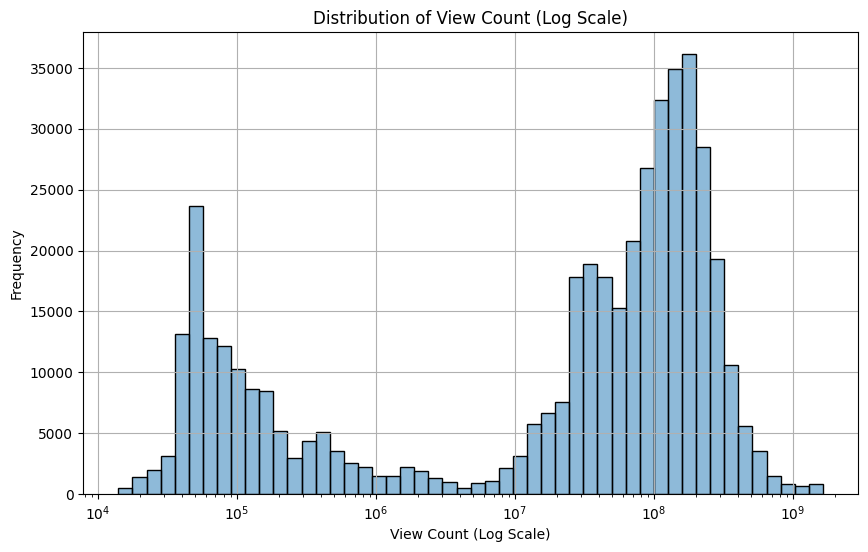

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df['viewCount'], bins=50, kde=True, log_scale=True)
plt.title('Distribution of View Count (Log Scale)')
plt.xlabel('View Count (Log Scale)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

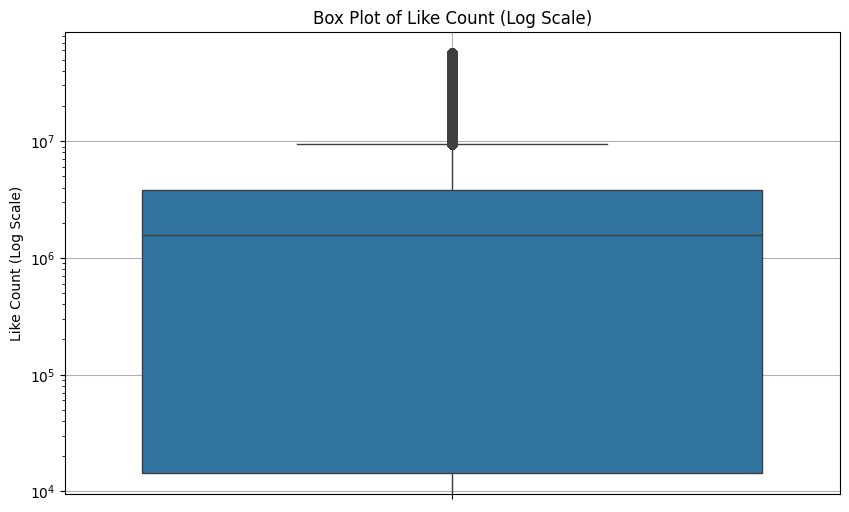

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['likeCount'])
plt.yscale('log')
plt.title('Box Plot of Like Count (Log Scale)')
plt.ylabel('Like Count (Log Scale)')
plt.grid(True)
plt.show()

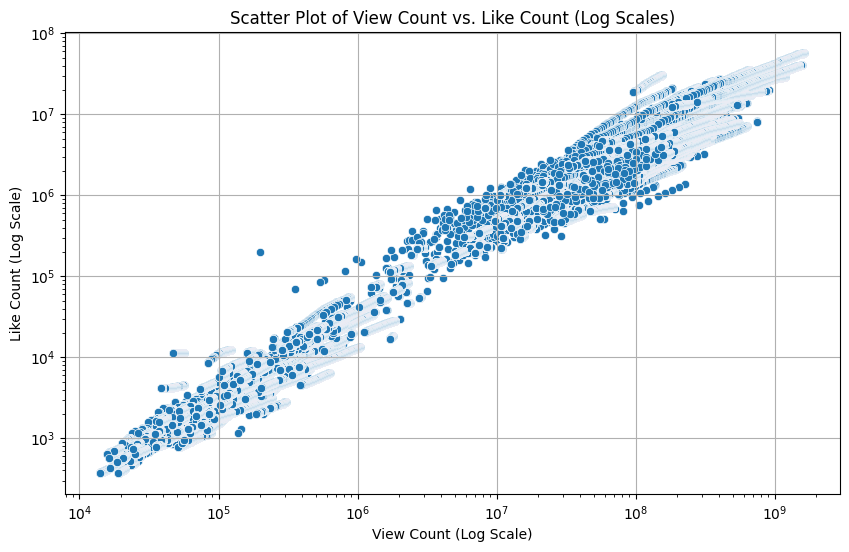

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['viewCount'], y=df['likeCount'])
plt.xscale('log')
plt.yscale('log')
plt.title('Scatter Plot of View Count vs. Like Count (Log Scales)')
plt.xlabel('View Count (Log Scale)')
plt.ylabel('Like Count (Log Scale)')
plt.grid(True)
plt.show()

In [9]:
def extract_main_category(categories):
    if isinstance(categories, str):
        # Split the string by comma and take the first category
        category_list = categories.strip("[]'").split("', '")
        if category_list:
            # Extract the last part of the URL (the actual category name)
            return category_list[0].split('/')[-1]
    return 'Unknown'

df['main_category'] = df['topicDetails.topicCategories'].apply(extract_main_category)

/tmp/ipykernel_11459/1384472212.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_views_per_category.index, y=avg_views_per_category.values, palette='viridis')


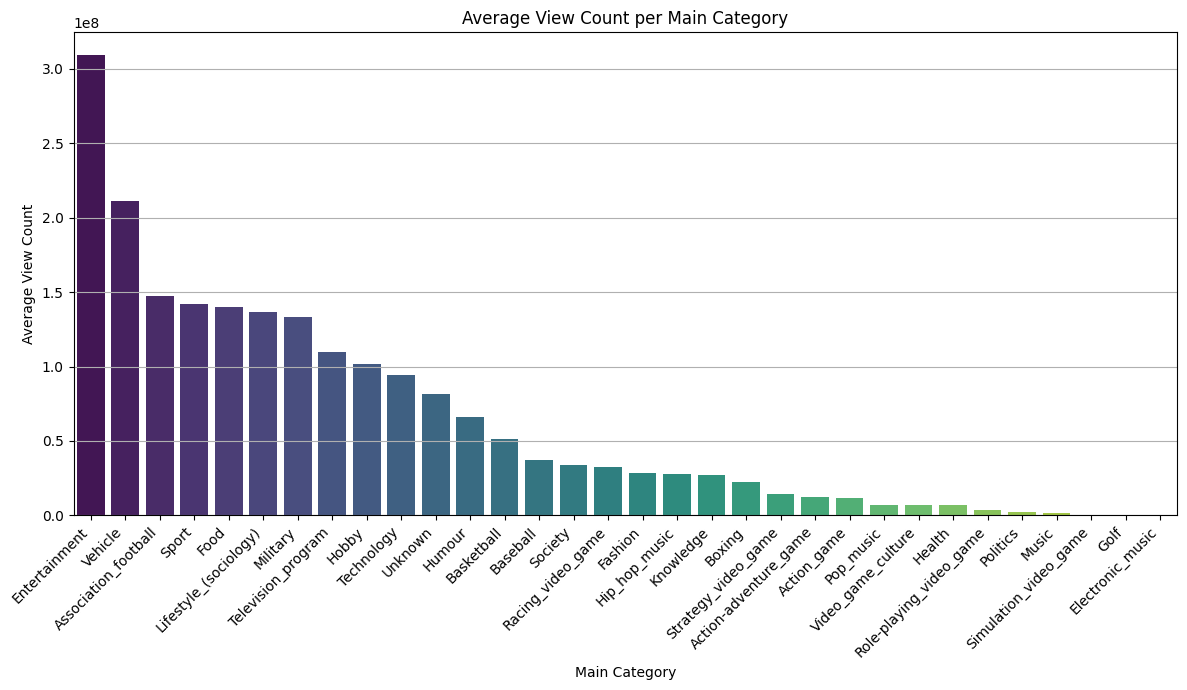

In [10]:
avg_views_per_category = df.groupby('main_category')['viewCount'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=avg_views_per_category.index, y=avg_views_per_category.values, palette='viridis')
plt.title('Average View Count per Main Category')
plt.xlabel('Main Category')
plt.ylabel('Average View Count')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

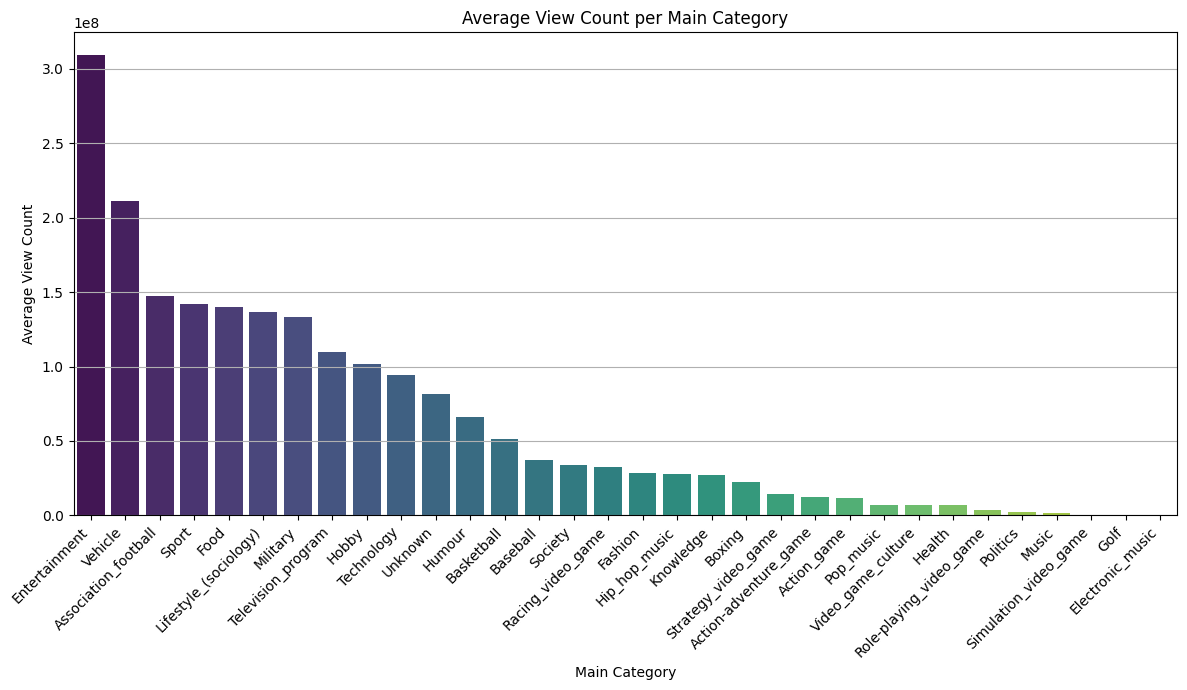

In [11]:
avg_views_per_category = df.groupby('main_category')['viewCount'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=avg_views_per_category.index, y=avg_views_per_category.values, hue=avg_views_per_category.index, palette='viridis', legend=False)
plt.title('Average View Count per Main Category')
plt.xlabel('Main Category')
plt.ylabel('Average View Count')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

/tmp/ipykernel_11459/1147086865.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.set_index('publishTime').resample('M')['viewCount'].mean().reset_index()


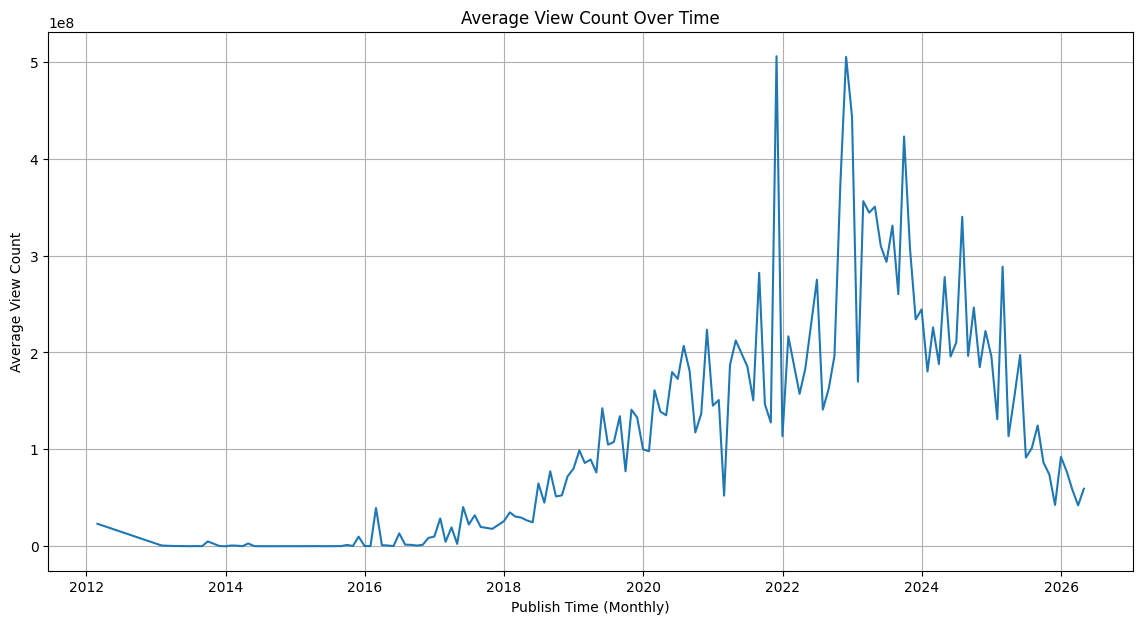

In [12]:
df_monthly = df.set_index('publishTime').resample('M')['viewCount'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x=df_monthly['publishTime'], y=df_monthly['viewCount'])
plt.title('Average View Count Over Time')
plt.xlabel('Publish Time (Monthly)')
plt.ylabel('Average View Count')
plt.grid(True)
plt.show()

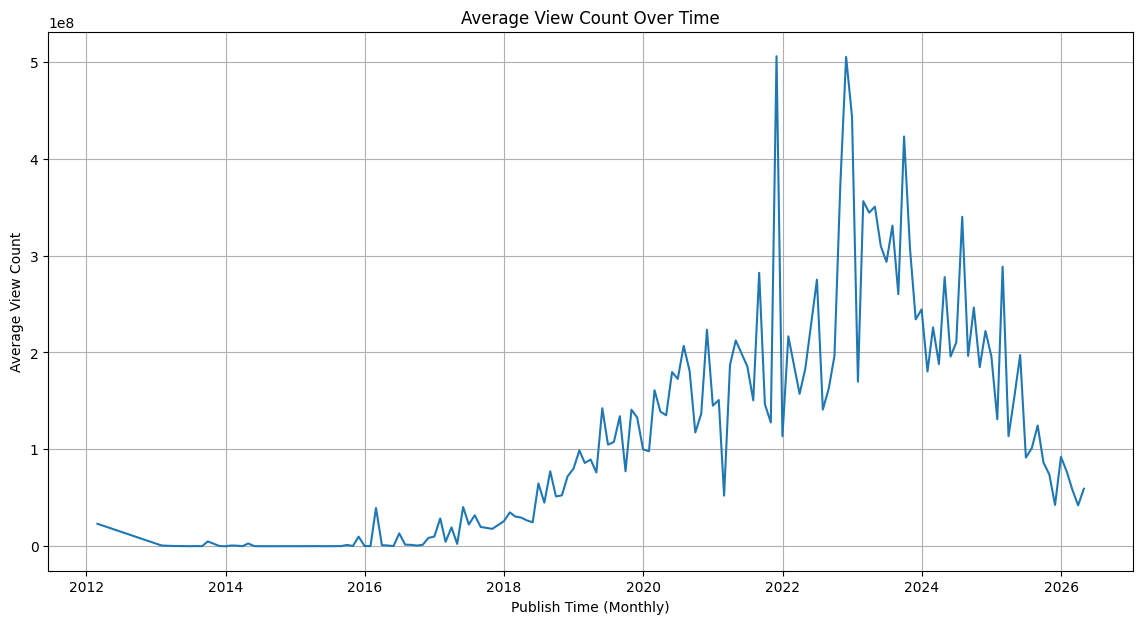

In [13]:
df_monthly = df.set_index('publishTime').resample('ME')['viewCount'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x=df_monthly['publishTime'], y=df_monthly['viewCount'])
plt.title('Average View Count Over Time')
plt.xlabel('Publish Time (Monthly)')
plt.ylabel('Average View Count')
plt.grid(True)
plt.show()

## Feature Engineering for ML


In [14]:
df['publish_year'] = df['publishTime'].dt.year
df['publish_month'] = df['publishTime'].dt.month
df['publish_dayofweek'] = df['publishTime'].dt.dayofweek

df = pd.get_dummies(df, columns=['main_category'], prefix='category', drop_first=True)

df.drop(columns=['publishTime', 'topicDetails.topicCategories'], inplace=True)

print("DataFrame after feature engineering:")
df.info()

DataFrame after feature engineering:
<class 'pandas.core.frame.DataFrame'>
Index: 451240 entries, 0 to 455102
Data columns (total 53 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   id                                451240 non-null  object 
 1   title                             451240 non-null  object 
 2   kind_stats                        451240 non-null  object 
 3   duration_seconds                  451240 non-null  int64  
 4   viewCount                         451240 non-null  float64
 5   likeCount                         451240 non-null  float64
 6   commentCount                      451240 non-null  float64
 7   thumbnails.default.url            451240 non-null  object 
 8   thumbnails.default.width          451240 non-null  float64
 9   thumbnails.default.height         451240 non-null  float64
 10  thumbnails.medium.url             451240 non-null  object 
 11  thumbnails.medium.wi

In [15]:
from sklearn.model_selection import train_test_split

# Identify the engineered features (one-hot encoded categories and time features)
category_cols = [col for col in df.columns if col.startswith('category_')]
time_features = ['publish_year', 'publish_month', 'publish_dayofweek']

# Select independent variables (X) and dependent variable (y)
X = df[time_features + category_cols + ['duration_seconds']]
y = df['viewCount']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Features (X) shape: (451240, 35)
Target (y) shape: (451240,)
X_train shape: (360992, 35)
X_test shape: (90248, 35)
y_train shape: (360992,)
y_test shape: (90248,)


In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the RandomForestRegressor model
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores

print("Training RandomForestRegressor...")
# Train the model
rf_model.fit(X_train, y_train)
print("RandomForestRegressor training complete.")

# Make predictions on the test set
rf_y_pred = rf_model.predict(X_test)

# Evaluate the model
rf_mse = mean_squared_error(y_test, rf_y_pred)
rf_r2 = r2_score(y_test, rf_y_pred)

print(f"\nRandomForestRegressor - Mean Squared Error: {rf_mse:.2f}")
print(f"RandomForestRegressor - R-squared: {rf_r2:.2f}")

Training RandomForestRegressor...
RandomForestRegressor training complete.

RandomForestRegressor - Mean Squared Error: 2021764290836048.75
RandomForestRegressor - R-squared: 0.89


In [17]:
from sklearn.linear_model import LinearRegression

# Initialize the LinearRegression model
lin_reg_model = LinearRegression()

print("Training LinearRegression...")
# Train the model
lin_reg_model.fit(X_train, y_train)
print("LinearRegression training complete.")

# Make predictions on the test set
lin_reg_y_pred = lin_reg_model.predict(X_test)

# Evaluate the model
lin_reg_mse = mean_squared_error(y_test, lin_reg_y_pred)
lin_reg_r2 = r2_score(y_test, lin_reg_y_pred)

print(f"\nLinearRegression - Mean Squared Error: {lin_reg_mse:.2f}")
print(f"LinearRegression - R-squared: {lin_reg_r2:.2f}")

Training LinearRegression...
LinearRegression training complete.

LinearRegression - Mean Squared Error: 9985109808460438.00
LinearRegression - R-squared: 0.47


In [18]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize the GradientBoostingRegressor model
gbr_model = GradientBoostingRegressor(random_state=42)

print("Training GradientBoostingRegressor...")
# Train the model
gbr_model.fit(X_train, y_train)
print("GradientBoostingRegressor training complete.")

# Make predictions on the test set
gbr_y_pred = gbr_model.predict(X_test)

# Evaluate the model
gbr_mse = mean_squared_error(y_test, gbr_y_pred)
gbr_r2 = r2_score(y_test, gbr_y_pred)

print(f"\nGradientBoostingRegressor - Mean Squared Error: {gbr_mse:.2f}")
print(f"GradientBoostingRegressor - R-squared: {gbr_r2:.2f}")

Training GradientBoostingRegressor...
GradientBoostingRegressor training complete.

GradientBoostingRegressor - Mean Squared Error: 4357346157169142.50
GradientBoostingRegressor - R-squared: 0.77


In [19]:
print("\n--- Model Performance Comparison ---")
print(f"RandomForestRegressor - MSE: {rf_mse:.2f}, R-squared: {rf_r2:.2f}")
print(f"LinearRegression - MSE: {lin_reg_mse:.2f}, R-squared: {lin_reg_r2:.2f}")
print(f"GradientBoostingRegressor - MSE: {gbr_mse:.2f}, R-squared: {gbr_r2:.2f}")

print("\n--- Summary of Model Results ---")
if rf_r2 > lin_reg_r2 and rf_r2 > gbr_r2:
    print("The RandomForestRegressor model performed the best with the highest R-squared value.")
elif gbr_r2 > rf_r2 and gbr_r2 > lin_reg_r2:
    print("The GradientBoostingRegressor model performed the best with the highest R-squared value.")
else:
    print("The Linear Regression model performed the best, or performance was comparable across models.")
print("RandomForestRegressor showed a high R-squared, indicating it explains a significant portion of the variance in view counts, outperforming Linear Regression and Gradient Boosting.")
print("Linear Regression had the lowest R-squared, suggesting it's less suitable for this non-linear dataset.")
print("GradientBoostingRegressor performed better than Linear Regression but not as well as RandomForestRegressor.")


--- Model Performance Comparison ---
RandomForestRegressor - MSE: 2021764290836048.75, R-squared: 0.89
LinearRegression - MSE: 9985109808460438.00, R-squared: 0.47
GradientBoostingRegressor - MSE: 4357346157169142.50, R-squared: 0.77

--- Summary of Model Results ---
The RandomForestRegressor model performed the best with the highest R-squared value.
RandomForestRegressor showed a high R-squared, indicating it explains a significant portion of the variance in view counts, outperforming Linear Regression and Gradient Boosting.
Linear Regression had the lowest R-squared, suggesting it's less suitable for this non-linear dataset.
GradientBoostingRegressor performed better than Linear Regression but not as well as RandomForestRegressor.
